# Final Project Part 3

In [9]:
#import relevant datasets 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Load the Dataset

In [10]:
#loading in dataset
file_path = r"/Users/amyhunt/PycharmProjects/BIOS584/Students Social Media Addiction.csv"
df = pd.read_csv(file_path)

#inspect first few rows of data
print(df.head())

   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Soc

## Part 2: Create Models

### Model 1: Assess Usage & Sleep

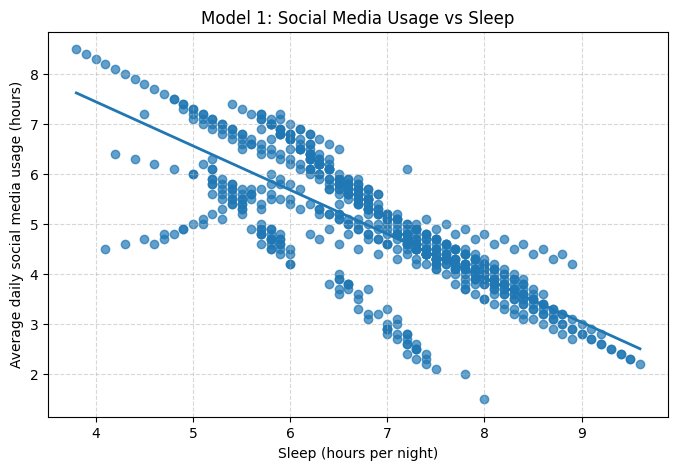

In [14]:
#create usage categories (low/medium/high)

usage = df["Avg_Daily_Usage_Hours"]

#have to use 33% and 67% quantiles to split into 3 equal-sized groups
bins = [
    usage.min() - 0.01,
    usage.quantile(1 / 3),
    usage.quantile(2 / 3),
    usage.max() + 0.01,
]
labels = ["Low", "Medium", "High"]

df["Usage_Category"] = pd.cut(usage, bins=bins, labels=labels)


#Making Model 1: Usage vs Sleep

plt.figure(figsize=(8, 5))

x = df["Sleep_Hours_Per_Night"]
y = df["Avg_Daily_Usage_Hours"]

#make scatter plot
plt.scatter(x, y, alpha=0.7)

#make regression line
coeffs = np.polyfit(x, y, 1)  #degree 1 -> linear
reg_line = np.poly1d(coeffs)
x_vals = np.linspace(x.min(), x.max(), 100)
plt.plot(x_vals, reg_line(x_vals), linewidth=2)

plt.xlabel("Sleep (hours per night)")
plt.ylabel("Average daily social media usage (hours)")
plt.title("Model 1: Social Media Usage vs Sleep")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Model 2: Usage & Conflict

<Figure size 800x500 with 0 Axes>

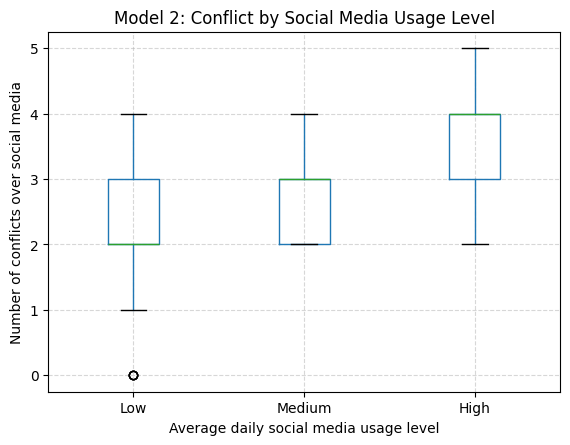

In [12]:
#Making Model 2: Usage vs Conflict

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Conflicts_Over_Social_Media",
    by="Usage_Category",
)

plt.xlabel("Average daily social media usage level")
plt.ylabel("Number of conflicts over social media")
plt.title("Model 2: Conflict by Social Media Usage Level")
plt.suptitle("")  #remove automatic subtitle
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Model 3: Usage & Relationship Status

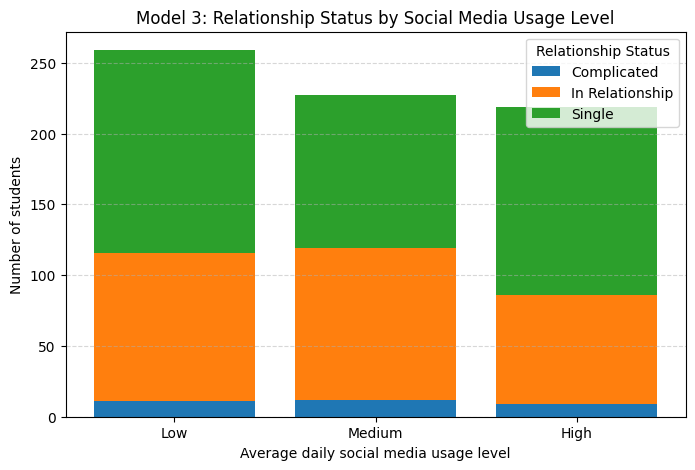

In [13]:
#Making Model 3: Usage vs Relationship Status

plt.figure(figsize=(8, 5))

#counts of relationship status within each usage category
crosstab_rel = pd.crosstab(df["Usage_Category"], df["Relationship_Status"])

#create stacked bar chart
bottom_vals = np.zeros(len(crosstab_rel))
x_positions = np.arange(len(crosstab_rel.index))

for status in crosstab_rel.columns:
    plt.bar(
        x_positions,
        crosstab_rel[status],
        bottom=bottom_vals,
        label=status,
    )
    bottom_vals += crosstab_rel[status].values

plt.xticks(x_positions, crosstab_rel.index.astype(str))
plt.xlabel("Average daily social media usage level")
plt.ylabel("Number of students")
plt.title("Model 3: Relationship Status by Social Media Usage Level")
plt.legend(title="Relationship Status")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.show()